# DSO 530 Group Project: Classification (CS)

## Cross-Validated Model Comparison

This notebook keeps Kailin's data cleaning and feature engineering exactly as she wrote them. After her work ends, the classification section is rebuilt to:

1. Drop `total_claims_history` (X.17) so the model only uses features available in the test set.
2. Run 5-fold stratified cross-validation on three model families: Logistic Regression with L1 regularization, Random Forest, and XGBoost.
3. Tune each model's hyperparameters with a moderate grid via `GridSearchCV`.
4. Auto-select the model with the highest cross-validated AUC.
5. Sweep decision thresholds to find the value that maximizes F1 on the claim class.
6. Retrain the chosen model on the full training set and produce predictions for the held-out test CSV.

## Target definitions

  - LC   = X.15 / X.16          if X.16 > 0, else 0
  - HALC = (X.15 / X.16) * X.18 if X.16 > 0, else 0
  - CS   = 1 if X.16 > 0, else 0   (the target for this notebook)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/machine_ learning_files/insurance_train2026.csv')
test = pd.read_csv('/content/drive/MyDrive/machine_ learning_files/insurance_test2026.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (39928, 28)
Test shape: (13310, 23)


### Rename columns from X.1..X.28 to descriptive names
Renaming the variables to descriptive names to make the code much more readable and interpretable for later modeling.

In [ ]:
rename_map = {
    'X.1':  'contract_id',
    'X.2':  'contract_start_date',  # all date columns following the format (DD/MM/YYYY)
    'X.3':  'last_renewal_date',
    'X.4':  'next_renewal_date',
    'X.5':  'birth_date',           # Date of birth of the insured declared in the policy
    'X.6':  'license_date',         # Date of issuance of the insured person’s driver’s license
    'X.7':  'channel',              # Channel through which the policy was contracted. 0=Agent, 1=Broker
    'X.8':  'tenure_years',         # Total number of years that the insured has been associated with the insurance entity
    'X.9':  'num_policies',         # Total number of policies held by the insured in the insurance entity
    'X.10': 'max_policies_ever',
    'X.11': 'max_products_simul',   # Maximum number of products that the insured has simultaneously held at any given point
    'X.12': 'policies_canceled',
    'X.13': 'payment_method',       # 0=annual, 1=half-yearly
    'X.14': 'net_premium',          # Net premium amount associated with the policy during the current year.
    'X.15': 'claim_cost',           # Total cost of claims for the insurance policy during the current year.
    'X.16': 'num_claims',           # Total number of claims incurred for the insurance policy during the current year.
    'X.17': 'total_claims_history',
    'X.18': 'claims_ratio',         # claims filed / years in force
    'X.19': 'risk_type',            # 1=motorbike, 2=van, 3=car, 4=agricultural
    'X.20': 'is_urban',             # 0=rural, 1=urban (>30k inhabitants)
    'X.21': 'multiple_drivers',     # 0=single, 1=multiple drivers being declared
    'X.22': 'vehicle_reg_year',     # (YYYY)
    'X.23': 'horsepower',           # Vehicle power measured in horsepower
    'X.24': 'cylinder_capacity',    # Cylinder capacity of the vehicle.
    'X.25': 'market_value',         # Market value of the vehicle as of 31/12/2019.
    'X.26': 'num_doors',            # Number of vehicle doors
    'X.27': 'fuel_type',            # P=Petrol, D=Diesel
    'X.28': 'vehicle_weight',       # Vehicle weight in kilograms
}

In [ ]:
train.rename(columns=rename_map, inplace=True)
display(train.head())

,contract_id,contract_start_date,last_renewal_date,next_renewal_date,birth_date,license_date,channel,tenure_years,num_policies,max_policies_ever,...,risk_type,is_urban,multiple_drivers,vehicle_reg_year,horsepower,cylinder_capacity,market_value,num_doors,fuel_type,vehicle_weight
0,47839,14/07/2016,14/07/2017,14/07/2018,23/02/1962,08/07/1985,1,2,1,1,...,3,0,0,2002,60,1686,10776.15,5,D,1045
1,21188,18/07/2015,18/07/2016,18/07/2017,05/04/1986,15/02/2005,0,2,1,1,...,3,0,0,2008,112,1598,21400.00,3,D,1090
2,21426,22/09/2017,22/09/2018,22/09/2019,31/03/1991,20/01/2013,1,4,1,2,...,3,0,0,2008,150,1995,31200.00,4,D,1415
3,4755,12/07/2016,12/07/2016,12/07/2017,25/10/1972,12/12/1991,0,1,1,1,...,2,0,0,1989,60,1769,12068.32,4,D,970
4,27707,30/01/2014,30/01/2016,30/01/2017,26/07/1974,24/03/1993,0,3,1,1,...,3,0,0,2003,100,1870,24160.00,5,D,1315


In [ ]:
test.rename(columns={k: v for k, v in rename_map.items() if k in test.columns}, inplace=True)
display(test.head())

,contract_start_date,last_renewal_date,next_renewal_date,birth_date,license_date,channel,tenure_years,num_policies,max_policies_ever,max_products_simul,...,risk_type,is_urban,multiple_drivers,vehicle_reg_year,horsepower,cylinder_capacity,market_value,num_doors,fuel_type,vehicle_weight
0,13/08/2015,13/08/2016,13/08/2017,31/10/1970,20/12/2002,0,2,1,1,1,...,3,1,0,2000,80,1686,16427.04,5,D,1205
1,16/09/2011,16/09/2018,16/09/2019,28/09/1968,10/11/1986,0,21,2,2,1,...,2,0,0,2011,120,2198,34425.00,5,D,1925
2,14/01/2014,14/01/2018,14/01/2019,01/01/1977,21/01/2005,0,5,1,1,1,...,3,0,0,2007,90,2497,29264.60,4,D,1230
3,05/07/2015,05/07/2018,05/07/2019,04/07/1964,29/04/1996,1,4,1,1,1,...,3,0,0,2007,115,1753,21245.00,5,D,1416
4,08/11/2018,08/11/2018,08/11/2019,10/07/1978,07/06/1997,1,1,2,2,1,...,1,1,0,2018,12,125,3389.00,0,P,137


There are columns in train dataset but not in test dataset: X.1, X.15, X.16, X.17, X.18.

**X.1**: Internal identification number assigned to each annual contract formalized by an insured.

**X.15**: Total cost of claims for the insurance policy during the current year.

**X.16**: Total number of claims incurred for the insurance policy during the current year.

**X.17**: Total number of claims filed throughout the entire duration of the policy.

**X.18**: Ratio of the number of claims filed to the total duration (years) of the policy in force.

### Data Inspection

In [ ]:
# train dataset data types
print("\nData Types")
print(train.dtypes)

print("\nBasic Statistics (Train)")
display(train.describe().round(2))

# missing values
print("\nMissing Values")
for name, df in [('Train', train), ('Test', test)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"  {name}: {dict(missing)}")
    else:
        print(f"  {name}: No missing values")

# check duplicates
print(f"\nDuplicate Rows in Train: {train.duplicated().sum()}")
print(f"\nDuplicate Rows in Test: {test.duplicated().sum()}")


Data Types
contract_id               int64
contract_start_date      object
last_renewal_date        object
next_renewal_date        object
birth_date               object
license_date             object
channel                   int64
tenure_years              int64
num_policies              int64
max_policies_ever         int64
max_products_simul        int64
policies_canceled         int64
payment_method            int64
net_premium             float64
claim_cost              float64
num_claims                int64
total_claims_history      int64
claims_ratio            float64
risk_type                 int64
is_urban                  int64
multiple_drivers          int64
vehicle_reg_year          int64
horsepower                int64
cylinder_capacity         int64
market_value            float64
num_doors                 int64
fuel_type                object
vehicle_weight            int64
dtype: object

Basic Statistics (Train)


,contract_id,channel,tenure_years,num_policies,max_policies_ever,max_products_simul,policies_canceled,payment_method,net_premium,claim_cost,...,claims_ratio,risk_type,is_urban,multiple_drivers,vehicle_reg_year,horsepower,cylinder_capacity,market_value,num_doors,vehicle_weight
count,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,...,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00,39928.00
mean,26783.39,0.48,5.74,1.51,1.86,1.06,0.38,0.34,321.14,110.45,...,0.47,2.73,0.27,0.13,2004.85,93.88,1625.65,18648.19,4.10,1196.19
std,15435.27,0.50,5.86,1.03,1.22,0.25,0.56,0.47,143.95,910.79,...,0.82,0.60,0.45,0.33,6.68,36.72,589.73,9221.96,1.48,437.75
min,1.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,40.18,0.00,...,0.00,1.00,0.00,0.00,1950.00,0.00,49.00,270.46,0.00,43.00
25%,13406.00,0.00,2.00,1.00,1.00,1.00,0.00,0.00,243.71,0.00,...,0.00,3.00,0.00,0.00,2001.00,75.00,1390.00,13250.00,4.00,1050.00
50%,26796.00,0.00,4.00,1.00,2.00,1.00,0.00,0.00,296.32,0.00,...,0.00,3.00,0.00,0.00,2005.00,92.00,1598.00,17832.50,5.00,1213.00
75%,40096.25,1.00,7.00,2.00,2.00,1.00,1.00,1.00,368.53,0.00,...,0.67,3.00,1.00,0.00,2008.00,110.00,1910.00,22840.00,5.00,1390.00
max,53502.00,1.00,40.00,17.00,17.00,4.00,7.00,1.00,2596.77,59656.65,...,26.07,4.00,1.00,1.00,2018.00,560.00,6788.00,220675.80,6.00,7300.00



Missing Values
  Train: {'fuel_type': np.int64(453)}
  Test: {'fuel_type': np.int64(140)}

Duplicate Rows in Train: 0

Duplicate Rows in Test: 0


There are no duplicates in both datasets. Both the train and test datasets have missing values only in the **fuel_type** column.

**Train dataframe**: fuel_type has 453 missing values.

**Test dataframe**: fuel_type has 140 missing values.

In [ ]:
numeric_features = [
    'tenure_years', 'num_policies', 'max_policies_ever', 'max_products_simul',
    'policies_canceled', 'net_premium', 'claim_cost', 'num_claims',
    'total_claims_history', 'claims_ratio', 'horsepower', 'cylinder_capacity',
    'market_value', 'vehicle_weight', 'vehicle_reg_year', 'num_doors',
]

In [ ]:
# checking outliers
print("\nIQR OUTLIER DETECTION")
print("=" * 80)
print(f"{'Feature':<25} {'Q1':>10} {'Q3':>10} {'IQR':>10} "
      f"{'Low cut':>10} {'High cut':>10} {'#Low':>7} {'#High':>7} {'%Out':>7}")
print("-" * 80)
outlier_summary = []
for col in numeric_features:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    n_low = (train[col] < low).sum()
    n_high = (train[col] > high).sum()
    pct = (n_low + n_high) / len(train) * 100
    print(f"{col:<25} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} "
          f"{low:>10.2f} {high:>10.2f} {n_low:>7} {n_high:>7} {pct:>6.2f}%")
    outlier_summary.append({'feature': col, 'n_low': n_low, 'n_high': n_high, 'pct': pct})


IQR OUTLIER DETECTION
Feature                           Q1         Q3        IQR    Low cut   High cut    #Low   #High    %Out
--------------------------------------------------------------------------------
tenure_years                    2.00       7.00       5.00      -5.50      14.50       0    3541   8.87%
num_policies                    1.00       2.00       1.00      -0.50       3.50       0    1838   4.60%
max_policies_ever               1.00       2.00       1.00      -0.50       3.50       0    3215   8.05%
max_products_simul              1.00       1.00       0.00       1.00       1.00       0    2085   5.22%
policies_canceled               0.00       1.00       1.00      -1.50       2.50       0     162   0.41%
net_premium                   243.71     368.53     124.82      56.48     555.76     238    2365   6.52%
claim_cost                      0.00       0.00       0.00       0.00       0.00       0    4453  11.15%
num_claims                      0.00       0.00       0.

In [ ]:
print("\n" + "=" * 70)
print("EXTREME PERCENTILE VALUES  ")
print("=" * 70)
print(f"{'Feature':<25} {'Min':>10} {'P50':>10} {'P95':>10} "
      f"{'Max':>10}")
print("-" * 70)

for col in numeric_features:
    s = train[col]
    print(f"{col:<25} {s.min():>10.2f} {s.quantile(0.50):>10.2f} "
          f"{s.quantile(0.95):>10.2f} {s.max():>10.2f}")


EXTREME PERCENTILE VALUES  
Feature                          Min        P50        P95        Max
----------------------------------------------------------------------
tenure_years                    1.00       4.00      19.00      40.00
num_policies                    1.00       1.00       3.00      17.00
max_policies_ever               1.00       2.00       4.00      17.00
max_products_simul              1.00       1.00       2.00       4.00
policies_canceled               0.00       0.00       1.00       7.00
net_premium                    40.18     296.32     580.50    2596.77
claim_cost                      0.00       0.00     385.21   59656.65
num_claims                      0.00       0.00       1.00      18.00
total_claims_history            0.00       1.00      10.00      52.00
claims_ratio                    0.00       0.00       2.01      26.07
horsepower                      0.00      92.00     150.00     560.00
cylinder_capacity              49.00    1598.00    2477.00  

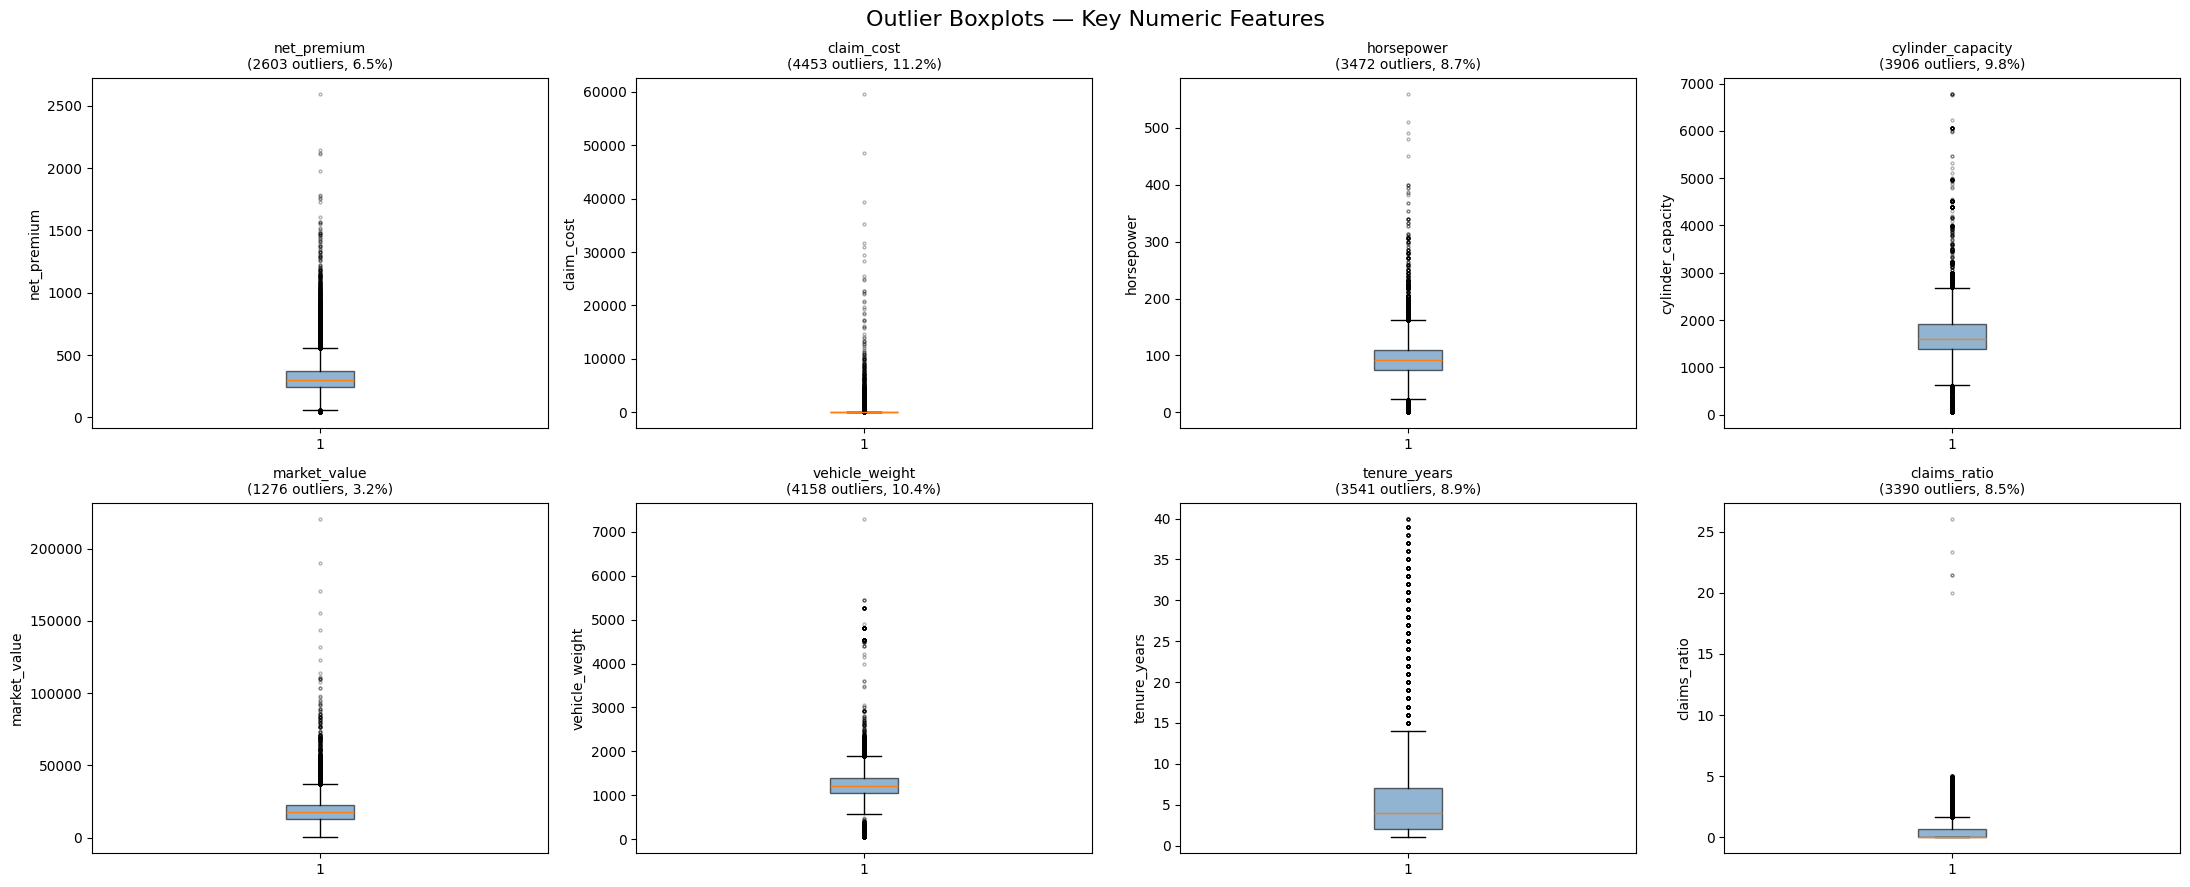

In [ ]:
# boxplot
plot_features = [
    'net_premium', 'claim_cost', 'horsepower', 'cylinder_capacity',
    'market_value', 'vehicle_weight', 'tenure_years', 'claims_ratio',
]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
fig.suptitle('Outlier Boxplots — Key Numeric Features', fontsize=16)

for i, col in enumerate(plot_features):
    ax = axes[i // 4, i % 4]
    data = train[col].dropna()
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    n_out = ((data < q1 - 1.5*iqr) | (data > q3 + 1.5*iqr)).sum()
    ax.set_title(f'{col}\n({n_out} outliers, {n_out/len(data)*100:.1f}%)', fontsize=10)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Data Sanity

In [ ]:
# negative value check
numeric_check_cols = ['tenure_years', 'num_policies', 'max_policies_ever',
                      'max_products_simul', 'policies_canceled', 'net_premium',
                      'claim_cost', 'num_claims', 'total_claims_history',
                      'horsepower', 'cylinder_capacity', 'market_value', 'vehicle_weight']
neg_issues = {c: (train[c] < 0).sum() for c in numeric_check_cols if (train[c] < 0).sum() > 0}
print(f"Negative values in positive-only columns")
print(f"  Issues: {neg_issues if neg_issues else 'None'}")

Negative values in positive-only columns
  Issues: None


In [ ]:
# convert all date columns to datetime
date_cols = ['contract_start_date', 'last_renewal_date', 'next_renewal_date',
             'birth_date', 'license_date']
for col in date_cols:
    train[col] = pd.to_datetime(train[col], format='%d/%m/%Y')
    test[col] = pd.to_datetime(test[col], format='%d/%m/%Y')

print("Date Ranges (Train)")
for col in date_cols:
    print(f"  {col}: {train[col].min().date()} to {train[col].max().date()}")

# date consistency checks
print("\nDate Consistency")
n_bad = (train['contract_start_date'] > train['last_renewal_date']).sum()
print(f"  contract_start > last_renewal: {n_bad} rows")
# These 35 rows have contract start after renewal — likely multi-year policies
# that renewed before the original start date passed. Keep them; the derived
# tenure feature will handle this.

print(f"  last_renewal >= next_renewal: "
      f"{(train['last_renewal_date'] >= train['next_renewal_date']).sum()} rows")

print(f"  born after getting license: "
      f"{(train['birth_date'] > train['license_date']).sum()} rows")

# Contract duration
contract_dur = (train['next_renewal_date'] - train['last_renewal_date']).dt.days
print(f"  Contract duration (next - last renewal): min={contract_dur.min()}, "
      f"max={contract_dur.max()} days")

Date Ranges (Train)
  contract_start_date: 1980-10-25 to 2018-11-30
  last_renewal_date: 2015-11-02 to 2018-11-30
  next_renewal_date: 2016-11-02 to 2019-11-30
  birth_date: 1918-04-05 to 2000-10-11
  license_date: 1942-10-01 to 2018-11-26

Date Consistency
  contract_start > last_renewal: 35 rows
  last_renewal >= next_renewal: 0 rows
  born after getting license: 0 rows
  Contract duration (next - last renewal): min=365, max=366 days


There are 35 rows having contract start after renewal, likely multi-year policies that renewed before the original start date passed.

In [ ]:
# age range
age_at_license = (train['license_date'] - train['birth_date']).dt.days / 365
age_at_renewal = (train['last_renewal_date'] - train['birth_date']).dt.days / 365
print(f"Age Checks")
print(f"  Age at license: min={age_at_license.min():.1f}, max={age_at_license.max():.1f}")
print(f"  Age at renewal: min={age_at_renewal.min():.1f}, max={age_at_renewal.max():.1f}")

Age Checks
  Age at license: min=18.0, max=72.9
  Age at renewal: min=18.1, max=98.6


In [ ]:
mask_hp0 = train['horsepower'] == 0
mask_fuel_na = train['fuel_type'].isnull()
print(f"  horsepower == 0: {mask_hp0.sum()}")
print(f"  fuel_type is NaN: {mask_fuel_na.sum()}")
print(f"  Both: {(mask_hp0 & mask_fuel_na).sum()}")
print(f"  vehicle type: "
      f"{train.loc[mask_hp0, 'risk_type'].value_counts().to_dict()}")

  horsepower == 0: 453
  fuel_type is NaN: 453
  Both: 453
  vehicle type: {1: 431, 4: 22}


The 453 missing records of fuel_type are belong to records of motorbikes and agricultural vehicles. We will address them in the feature engineering part.

In [ ]:
print(f"num_doors == 0")
print(f"  Count: {(train['num_doors'] == 0).sum()}")
print(f"  risk_type breakdown: "
      f"{train.loc[train['num_doors']==0, 'risk_type'].value_counts().to_dict()}")
# Consistent: motorbikes & agri vehicles have 0 doors

# check if num_claims>0 but claims_ratio==0
problem_halc = (train['num_claims'] > 0) & (train['claims_ratio'] == 0)
print(f"\nnum_claims>0 but claims_ratio=0")
print(f"  Count: {problem_halc.sum()}")
# HALC = LC * claims_ratio = LC * 0 = 0 for these rows, so no special handling needed

num_doors == 0
  Count: 3246
  risk_type breakdown: {1: 3014, 4: 232}

num_claims>0 but claims_ratio=0
  Count: 15


## Construct Target Variables and checks for imbalance

In [ ]:
# LC: Loss Cost per Exposure Unit
train['LC'] = np.where(train['num_claims'] > 0, train['claim_cost'] / train['num_claims'], 0.0)

# Historically Adjusted Loss Cost: HALC = LC * claims_ratio
train['HALC'] = np.where(train['num_claims'] > 0,
    (train['claim_cost'] / train['num_claims']) * train['claims_ratio'],
    0.0)

# Claim Status (binary)
train['CS'] = (train['num_claims'] > 0).astype(int)

In [ ]:
print(f"LC  — non-zero: {(train['LC']>0).sum()}/{len(train)} "
      f"({(train['LC']>0).mean()*100:.1f}%)")
print(f"mean(all)={train['LC'].mean():.2f}, "
      f"mean(non-zero)={train.loc[train['LC']>0, 'LC'].mean():.2f}, "
      f"median(non-zero)={train.loc[train['LC']>0, 'LC'].median():.2f}")

print(f"\nHALC — non-zero: {(train['HALC']>0).sum()}/{len(train)} "
      f"({(train['HALC']>0).mean()*100:.1f}%)")
print(f"mean(all)={train['HALC'].mean():.2f}, "
      f"mean(non-zero)={train.loc[train['HALC']>0, 'HALC'].mean():.2f}")

print(f"\nCS   — 0: {(train['CS']==0).sum()} ({(train['CS']==0).mean()*100:.1f}%), "
      f"1: {(train['CS']==1).sum()} ({(train['CS']==1).mean()*100:.1f}%)")

LC  — non-zero: 4453/39928 (11.2%)
mean(all)=63.93, mean(non-zero)=573.25, median(non-zero)=181.71

HALC — non-zero: 4438/39928 (11.1%)
mean(all)=116.11, mean(non-zero)=1044.59

CS   — 0: 35475 (88.8%), 1: 4453 (11.2%)


## FEATURE ENGINEERING

Missing fuel_type occurs only for motorbikes (risk_type=1) and agricultural vehicles (risk_type=4) that also have horsepower=0. Among recorded values: motorbikes are 99.5% Petrol, agri are 97.5% Diesel.Therefore we will impute with the dominant fuel type per risk_type, then encode.

**14 new features were created** including age, driving experience, vehicle age, vehicle value per kg, premium per unit of vehicle value, power-to-weight ratio, renewal month and quarter, and fuel/risk type encodings.

In [ ]:
def engineer_features(df):
  # Age of insured at last renewal
  df['age'] = (df['last_renewal_date'] - df['birth_date']).dt.days / 365

  # Driving experience (years since license at last renewal)
  df['driving_exp'] = (df['last_renewal_date'] - df['license_date']).dt.days / 365

  # Vehicle age at last renewal
  df['vehicle_age'] = df['last_renewal_date'].dt.year - df['vehicle_reg_year']

  # Age when got license
  df['age_at_license'] = (df['license_date'] - df['birth_date']).dt.days / 365.25

  # Power-to-weight ratio
  df['power_to_weight'] = np.where(df['vehicle_weight'] > 0, df['horsepower'] / df['vehicle_weight'],0)

  # Vehicle value per kg
  df['value_per_kg'] = np.where(df['vehicle_weight'] > 0, df['market_value'] / df['vehicle_weight'],0)

  # Premium per unit of vehicle value
  df['premium_to_value'] = np.where(df['market_value'] > 0, df['net_premium'] / df['market_value'], 0)

  # risk_type as dummies ---
  # 1=motorbike, 2=van, 3=passenger car, 4=agricultural
  df['risk_motorbike'] = (df['risk_type'] == 1).astype(int)
  df['risk_van'] = (df['risk_type'] == 2).astype(int)
  df['risk_car'] = (df['risk_type'] == 3).astype(int)
  df['risk_agri'] = (df['risk_type'] == 4).astype(int)

  # renewal month and quarter (can be used for checking seasonality)
  df['renewal_month'] = df['last_renewal_date'].dt.month
  df['renewal_quarter'] = df['last_renewal_date'].dt.quarter

  # impute fuel type
  df.loc[df['fuel_type'].isnull() & (df['risk_type'] == 1), 'fuel_type'] = 'P'
  df.loc[df['fuel_type'].isnull() & (df['risk_type'] == 4), 'fuel_type'] = 'D'
  df['fuel_diesel'] = (df['fuel_type'] == 'D').astype(int) # 1 = Diesel, 0 = Petrol

  return df

In [ ]:
# Apply feature engineering to both datasets
train = engineer_features(train)
test = engineer_features(test)

# Identify original vs engineered columns
ORIGINAL_COLS = list(rename_map.values())
print("New features created:")
new_cols = [c for c in train.columns if c not in ORIGINAL_COLS + ['LC', 'HALC', 'CS']]
for c in new_cols:
    print(f"{c}: min={train[c].min():.2f}, max={train[c].max():.2f}, "
          f"mean={train[c].mean():.2f}")

New features created:
age: min=18.13, max=98.60, mean=47.26
driving_exp: min=-0.47, max=74.08, mean=24.58
vehicle_age: min=0.00, max=68.00, mean=12.64
age_at_license: min=18.00, max=72.80, mean=22.66
power_to_weight: min=0.00, max=2.52, mean=0.08
value_per_kg: min=0.33, max=138.15, mean=16.16
premium_to_value: min=0.00, max=0.75, mean=0.02
risk_motorbike: min=0.00, max=1.00, mean=0.08
risk_van: min=0.00, max=1.00, mean=0.12
risk_car: min=0.00, max=1.00, mean=0.79
risk_agri: min=0.00, max=1.00, mean=0.01
renewal_month: min=1.00, max=12.00, mean=6.61
renewal_quarter: min=1.00, max=4.00, mean=2.54
fuel_diesel: min=0.00, max=1.00, mean=0.62


## EDA

### Key visual findings:

1. **Target distributions**: LC and HALC exhibit extreme right skew
even after removing zeros. The targets are heavily zero-inflated (88.8% zeros), confirming the Tweedie distribution approach mentioned in the project instructions. The class imbalance for CS is roughly 89:11. Log transformation produces a roughly normal shape for non-zero LC.
2. **Claim rates by category** : Vans (risk_type = 2) show the highest claim rate (15%), followed by passenger cars (10%), while motorbikes have the lowest (4%). Half-yearly payment (payment_method = 1) is associated with higher claim rates (16%) than annual payment (7%). Urban policyholders claim slightly more often than rural ones.
3. **Age and claim rate** : Claim rates are relatively flat across insured ages 25–75 (around 10–12%) with a dip for the youngest (<25) and oldest (>80) age groups. Vehicle age shows a gradual increase in claim rate from ~8% for newer vehicles to ~14% for vehicles aged 20–30 years, followed by a decline for very old vehicles (likely low-mileage classic vehicles).
4. **Correlation structure** : The vehicle specification cluster (horsepower, cylinder_capacity, market_value, vehicle_weight) forms a tightly correlated group, suggesting these variables capture a single underlying "vehicle size/value" dimension.

### Target distributions

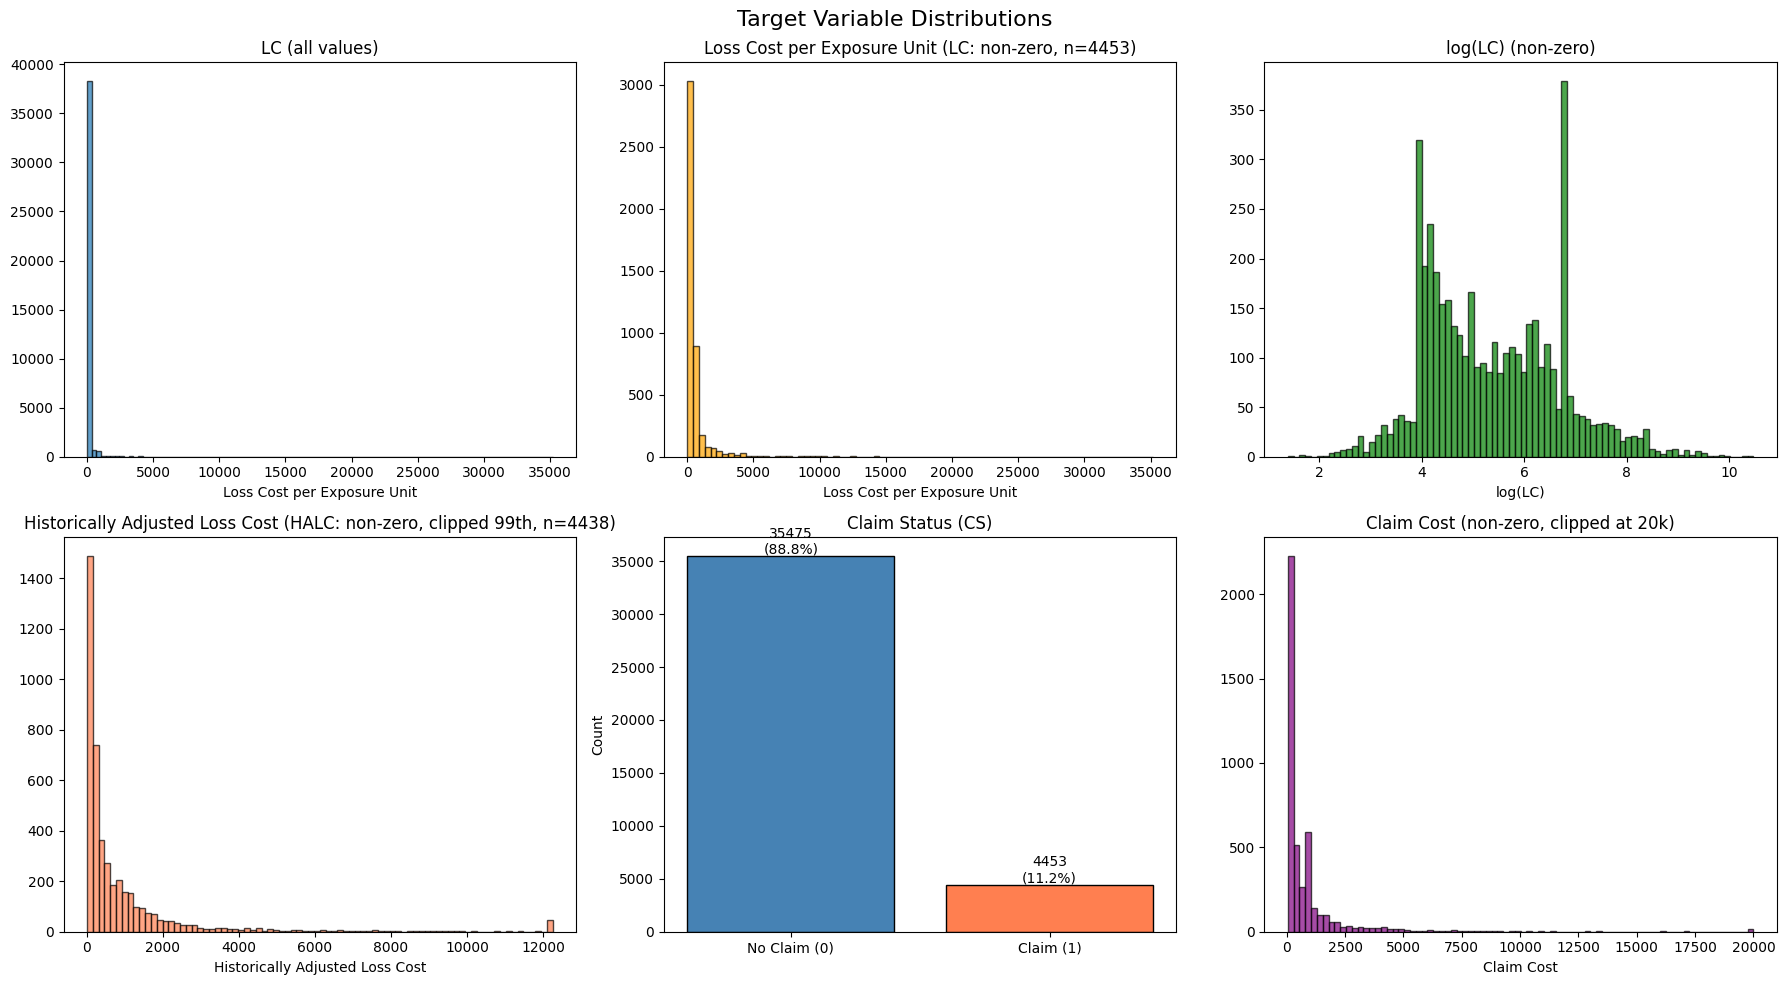

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Target Variable Distributions', fontsize=16)

# LC distribution (all)
axes[0, 0].hist(train['LC'], bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('LC (all values)')
axes[0, 0].set_xlabel('Loss Cost per Exposure Unit')

# LC distribution (non-zero only)
lc_nz = train.loc[train['LC'] > 0, 'LC']
axes[0, 1].hist(lc_nz, bins=80, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title(f'Loss Cost per Exposure Unit (LC: non-zero, n={len(lc_nz)})')
axes[0, 1].set_xlabel('Loss Cost per Exposure Unit')

# Log LC (non-zero)
axes[0, 2].hist(np.log(lc_nz), bins=80, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('log(LC) (non-zero)')
axes[0, 2].set_xlabel('log(LC)')

# HALC distribution (non-zero only)
halc_nz = train.loc[train['HALC'] > 0, 'HALC']
axes[1, 0].hist(halc_nz.clip(upper=halc_nz.quantile(0.99)), bins=80,
                edgecolor='black', alpha=0.7, color='coral')
axes[1, 0].set_title(f'Historically Adjusted Loss Cost (HALC: non-zero, clipped 99th, n={len(halc_nz)})')
axes[1, 0].set_xlabel('Historically Adjusted Loss Cost')

# CS distribution
cs_counts = train['CS'].value_counts().sort_index()
axes[1, 1].bar(['No Claim (0)', 'Claim (1)'], cs_counts.values,
               color=['steelblue', 'coral'], edgecolor='black')
axes[1, 1].set_title('Claim Status (CS)')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(cs_counts.values):
    axes[1, 1].text(i, v + 200, f'{v}\n({v/len(train)*100:.1f}%)', ha='center')

# Raw claim cost
axes[1, 2].hist(train.loc[train['claim_cost'] > 0, 'claim_cost'].clip(upper=20000),
                bins=80, edgecolor='black', alpha=0.7, color='purple')
axes[1, 2].set_title('Claim Cost (non-zero, clipped at 20k)')
axes[1, 2].set_xlabel('Claim Cost')

plt.tight_layout()
plt.show()

### Feature distributions for key numeric variables

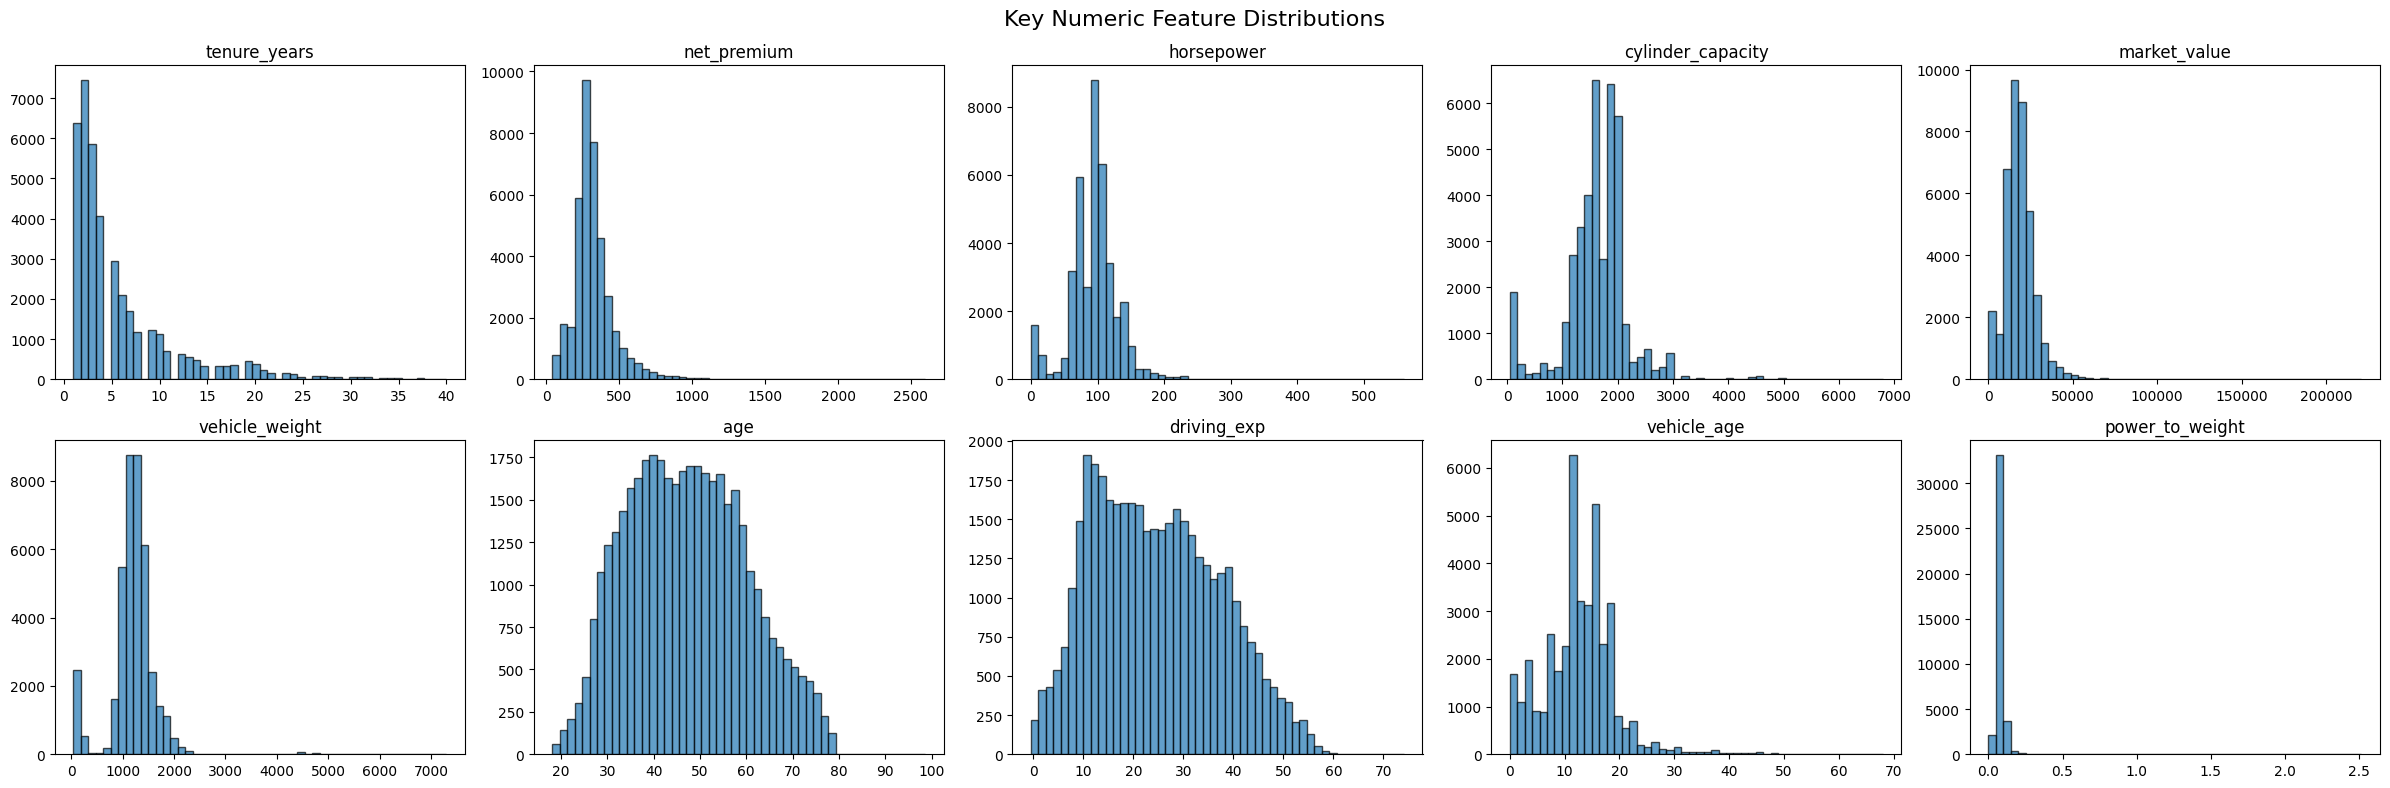

In [ ]:
num_features = ['tenure_years', 'net_premium', 'horsepower', 'cylinder_capacity',
                'market_value', 'vehicle_weight',
                'age', 'driving_exp', 'vehicle_age', 'power_to_weight']

fig, axes = plt.subplots(2, 5, figsize=(24, 8))
fig.suptitle('Key Numeric Feature Distributions', fontsize=16)
for i, col in enumerate(num_features):
    ax = axes[i // 5, i % 5]
    ax.hist(train[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

### Categorical feature distributions vs claim status

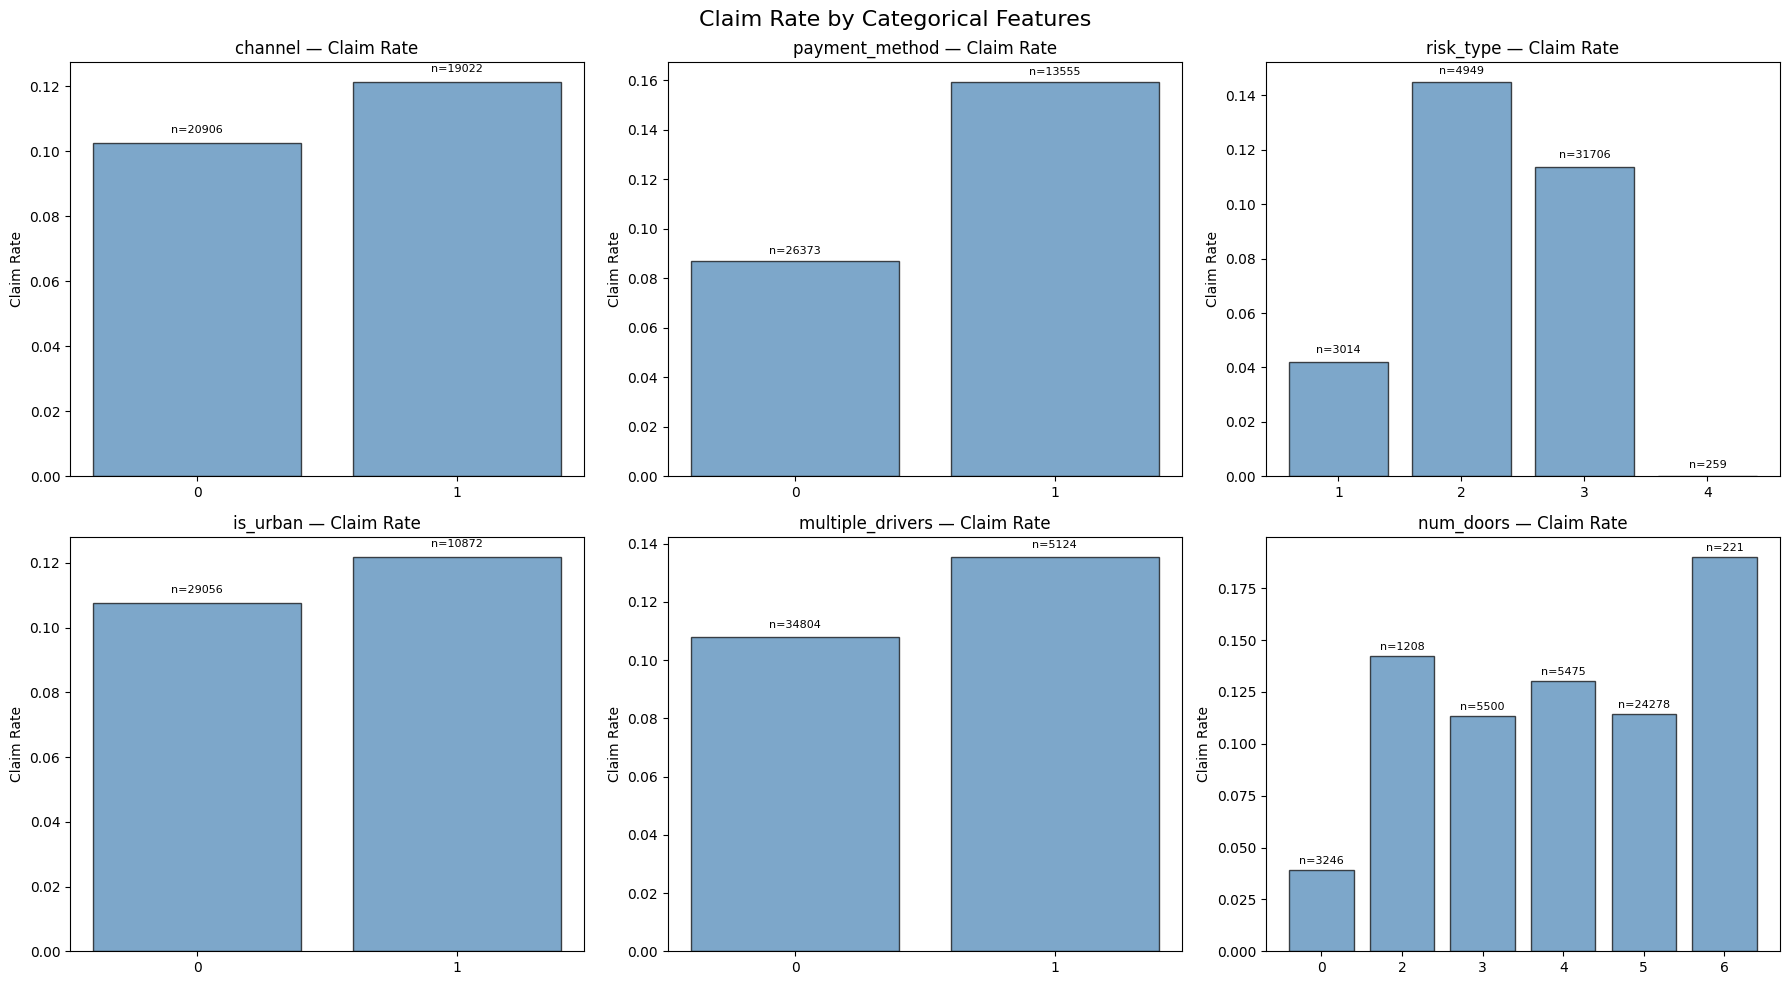

In [ ]:
cat_features = ['channel', 'payment_method', 'risk_type', 'is_urban',
                'multiple_drivers', 'num_doors']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Claim Rate by Categorical Features', fontsize=16)
for i, col in enumerate(cat_features):
    ax = axes[i // 3, i % 3]
    claim_rate = train.groupby(col)['CS'].mean()
    counts = train[col].value_counts().sort_index()
    bars = ax.bar(claim_rate.index.astype(str), claim_rate.values,color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{col} — Claim Rate')
    ax.set_ylabel('Claim Rate')
    # Add count labels
    for j, (idx, val) in enumerate(claim_rate.items()):
        ax.text(j, val + 0.003, f'n={counts[idx]}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### Correlation heatmap of numeric features

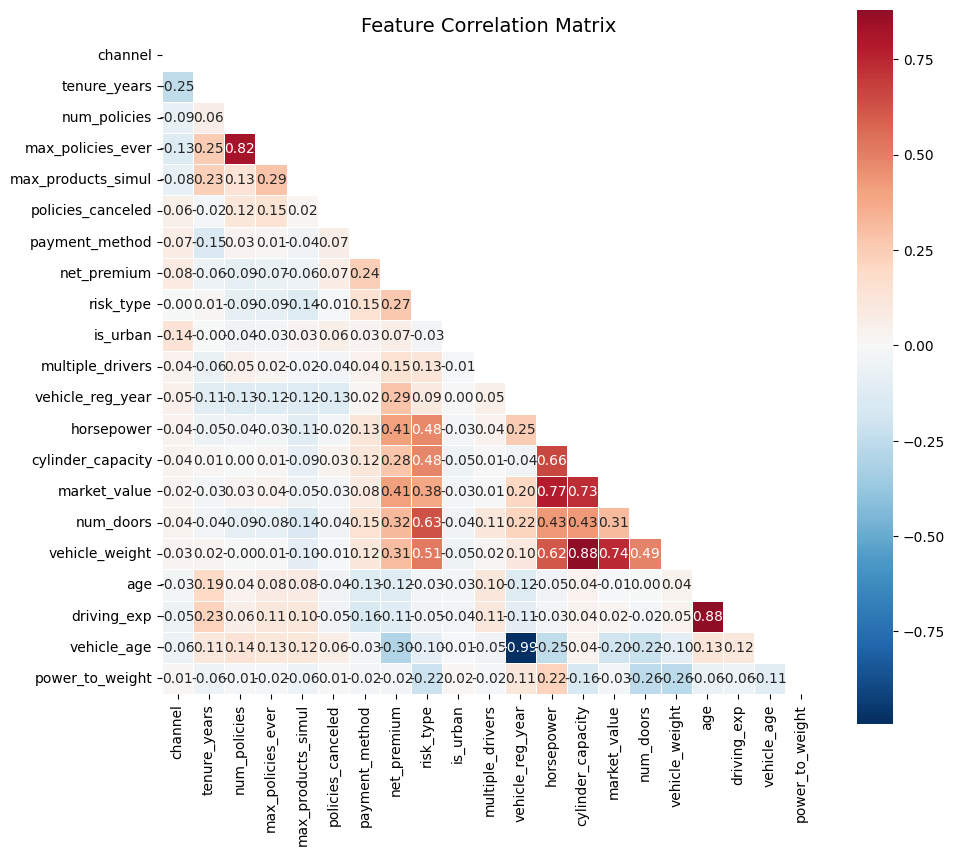

In [ ]:
corr_cols = ['channel', 'tenure_years', 'num_policies', 'max_policies_ever',
             'max_products_simul', 'policies_canceled', 'payment_method', 'net_premium',
             'risk_type', 'is_urban', 'multiple_drivers', 'vehicle_reg_year',
             'horsepower', 'cylinder_capacity', 'market_value', 'num_doors',
             'vehicle_weight', 'age', 'driving_exp', 'vehicle_age', 'power_to_weight']

fig, ax = plt.subplots(figsize=(10, 10))
corr_matrix = train[corr_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

### Claim rate by age bins and vehicle age

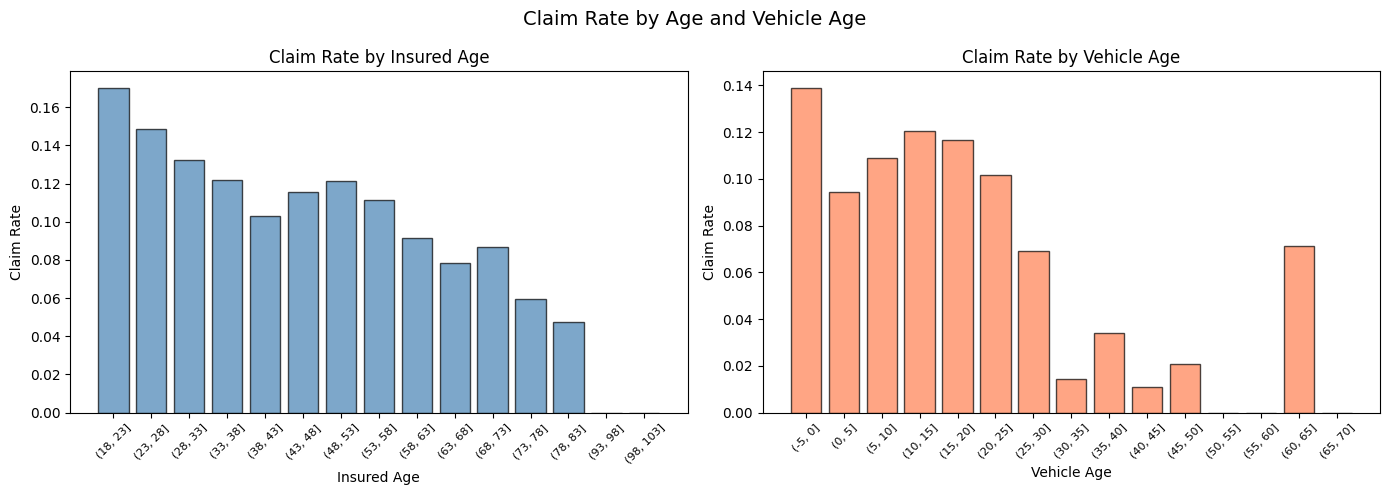

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Claim Rate by Age and Vehicle Age', fontsize=14)

# By insured age
train['age_bin'] = pd.cut(train['age'], bins=range(18, 105, 5))
age_claim = train.groupby('age_bin', observed=True)['CS'].agg(['mean', 'count'])
axes[0].bar(range(len(age_claim)), age_claim['mean'], color='steelblue',
            edgecolor='black', alpha=0.7)
axes[0].set_xticks(range(len(age_claim)))
axes[0].set_xticklabels([str(x) for x in age_claim.index], rotation=45, fontsize=8)
axes[0].set_title('Claim Rate by Insured Age')
axes[0].set_ylabel('Claim Rate')
axes[0].set_xlabel('Insured Age')

# By vehicle age
train['veh_age_bin'] = pd.cut(train['vehicle_age'], bins=range(-5, 75, 5))
veh_claim = train.groupby('veh_age_bin', observed=True)['CS'].agg(['mean', 'count'])
axes[1].bar(range(len(veh_claim)), veh_claim['mean'], color='coral',
            edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(veh_claim)))
axes[1].set_xticklabels([str(x) for x in veh_claim.index], rotation=45, fontsize=8)
axes[1].set_title('Claim Rate by Vehicle Age')
axes[1].set_ylabel('Claim Rate')
axes[1].set_xlabel('Vehicle Age')

plt.tight_layout()
plt.show()

# Drop temporary binning columns
train.drop(columns=['age_bin', 'veh_age_bin'], inplace=True)

### LC and HALC vs key features

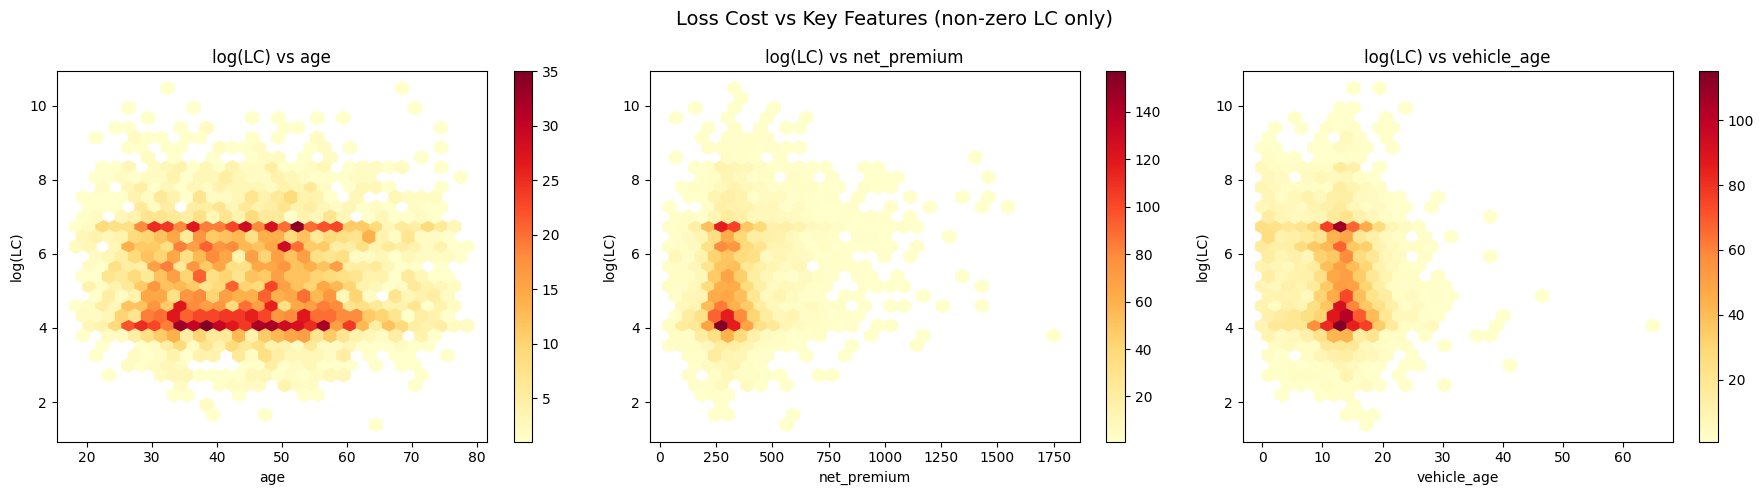

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Loss Cost vs Key Features (non-zero LC only)', fontsize=14)
nz = train[train['LC'] > 0]

for i, col in enumerate(['age', 'net_premium', 'vehicle_age']):
    axes[i].hexbin(nz[col], np.log(nz['LC']), gridsize=30, cmap='YlOrRd', mincnt=1)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log(LC)')
    axes[i].set_title(f'log(LC) vs {col}')
    plt.colorbar(axes[i].collections[0], ax=axes[i])

plt.tight_layout()
plt.show()

# Classification (CS) — Cross-Validated Model Comparison

Everything above this point is Kailin's data cleaning and feature engineering, unchanged. The rest of the notebook is the modeling pipeline for the classification target (CS).

## Pipeline overview

1. Build the modeling DataFrames and drop the leakage column `total_claims_history` (X.17).
2. Define preprocessing for each model. Logistic Regression needs feature scaling; tree models do not.
3. Run 5-fold stratified `GridSearchCV` on three model families. Logistic Regression with L1 penalty, Random Forest, and XGBoost.
4. Compare cross-validated AUC across the three models and auto-select the winner.
5. Sweep decision thresholds for the winning model to find the value that maximizes F1 on the claim class.
6. Retrain the winning model on the full training set and produce `CS_predictions.csv` for the test set.

Why these three families. Logistic regression with L1 gives a linear, coefficient-based baseline with built-in feature selection. Random Forest is a bagged tree ensemble that handles correlated features and outliers without much tuning. XGBoost is a boosted tree ensemble that often improves on Random Forest by 1 to 3 AUC points at the cost of more careful tuning. Together they cover linear, bagged, and boosted approaches to the same problem.

## Step 1: Build modeling DataFrames

We copy the cleaned training and test frames, add a few extra date-derived features, then drop columns that cannot be used as predictors.

Columns we drop fall into four groups.

1. Identifiers and raw dates (already converted into derived features).
2. Leakage variables that the test CSV does not contain. `claim_cost` (X.15), `num_claims` (X.16), `total_claims_history` (X.17), `claims_ratio` (X.18). Including any of these would inflate validation scores and crash at prediction time when the test frame is one column short.
3. Regression targets (`LC`, `HALC`) which are not predictors for the classification task.
4. The raw `fuel_type` string column, replaced earlier by the binary `fuel_diesel` indicator.

After dropping, we assert that the training and test feature columns match exactly. This catches any future column drift before it silently breaks the model.

In [ ]:
# Copy the cleaned frames so the classification work does not mutate the EDA frames
train_model = train.copy()
test_model = test.copy()

# Add a small set of extra date-derived features that did not exist in Kailin's set
def engineer_features_extra(df):
    # Days from last renewal to next renewal (essentially policy length, ~365 days)
    df['days_since_renewal'] = (df['next_renewal_date'] - df['last_renewal_date']).dt.days
    df['months_since_renewal'] = df['days_since_renewal'] / 30

    # Driving experience as a fraction of total age
    df['exp_to_age_ratio'] = (df['driving_exp'] / df['age']).replace([np.inf, -np.inf], 0)

    # Nonlinear vehicle age, lets a linear model approximate a curved relationship
    df['vehicle_age_squared'] = df['vehicle_age'] ** 2

    # Years since the policyholder got their license, calculated at last renewal
    df['license_age'] = (df['last_renewal_date'] - df['license_date']).dt.days / 365

    # Total contract length in days, from contract start to next renewal
    df['contract_length_days'] = (df['next_renewal_date'] - df['contract_start_date']).dt.days

    # Recompute month and quarter (already exist; recomputing is harmless)
    df['renewal_month'] = df['last_renewal_date'].dt.month
    df['renewal_quarter'] = df['last_renewal_date'].dt.quarter

    return df

train_model = engineer_features_extra(train_model)
test_model = engineer_features_extra(test_model)

# Drop columns we cannot or should not feed to the classifier
drop_cols = [
    'contract_id',                # identifier
    'contract_start_date',        # raw dates, replaced by derived features
    'last_renewal_date',
    'next_renewal_date',
    'birth_date',
    'license_date',
    'claim_cost',                 # withheld from test set (X.15)
    'num_claims',                 # withheld from test set (X.16)
    'total_claims_history',       # withheld from test set (X.17), the leakage fix
    'claims_ratio',               # withheld from test set (X.18)
    'LC', 'HALC',                 # regression targets, not classification predictors
    'fuel_type',                  # raw string, replaced by fuel_diesel
]
train_model.drop(columns=drop_cols, inplace=True)
test_model.drop(columns=drop_cols, inplace=True, errors='ignore')

# Split features and target
y_train_CS = train_model['CS']
X_train_CS = train_model.drop(columns=['CS'])
X_test_CS = test_model.copy()

# Force the test frame to use the same column order as the training frame
X_test_CS = X_test_CS[X_train_CS.columns]

# Sanity check: train and test must have identical columns at this point
assert X_train_CS.shape[1] == X_test_CS.shape[1], (
    'Train and test must have identical columns. '
    f'Train has but test does not: {set(X_train_CS.columns) - set(X_test_CS.columns)}. '
    f'Test has but train does not: {set(X_test_CS.columns) - set(X_train_CS.columns)}.'
)

print(f'X_train shape: {X_train_CS.shape}')
print(f'X_test shape : {X_test_CS.shape}')
print(f'Number of features: {X_train_CS.shape[1]}')
print(f'\nClass balance in y_train:')
print(y_train_CS.value_counts(normalize=True).round(3))

X_train shape: (39928, 37)
X_test shape : (13310, 37)
Number of features: 37

Class balance in y_train:
CS
0    0.888
1    0.112
Name: proportion, dtype: float64


## Step 2: Set up cross-validation

We use 5-fold `StratifiedKFold` so every fold preserves the 89:11 class balance. Stratification matters when the minority class is small, otherwise a fold could end up with very few or zero positives and produce unstable validation scores.

All three models will use the same `cv` object, the same `random_state`, and the same scoring metric (`roc_auc`). This is the only way to make their cross-validated AUC numbers directly comparable.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, f1_score

# Five-fold stratified CV. Same splits used for every model.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# We will use ROC-AUC as the primary scoring metric. AUC matches the project rubric.
scoring_metric = 'roc_auc'

# Shared random seed so model results are reproducible
RANDOM_STATE = 42

## Step 3: Logistic Regression with L1 regularization

Logistic regression assumes a linear relationship on the log-odds scale and is sensitive to feature scale. We wrap it in a scikit-learn `Pipeline` with `StandardScaler` so the scaler is fit inside each cross-validation fold (no leakage from validation into training).

We tune the regularization strength `C`. Lower `C` means stronger regularization, which pushes more coefficients to zero (built-in feature selection). The L1 penalty produces sparse models that are easier to interpret. We use `class_weight='balanced'` so the loss function compensates for the 89:11 imbalance.

Why `solver='liblinear'`. It is the recommended solver for L1 penalty on small to medium binary problems. `saga` works too but converges more slowly here.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline: scale features, then fit logistic regression with L1 penalty
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=2000,
    )),
])

# Moderate grid: four C values spanning four orders of magnitude
lr_param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0],
}

lr_grid = GridSearchCV(
    estimator=lr_pipe,
    param_grid=lr_param_grid,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print('Fitting Logistic Regression grid...')
lr_grid.fit(X_train_CS, y_train_CS)

print(f'\nBest C: {lr_grid.best_params_["clf__C"]}')
print(f'Best CV AUC: {lr_grid.best_score_:.4f}')

Fitting Logistic Regression grid...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best C: 0.1
Best CV AUC: 0.7791


## Step 4: Random Forest

Random Forest does not require scaling because trees split on raw feature values. We tune three hyperparameters.

1. `n_estimators` is the number of trees. More trees reduce variance but cost training time. We try 100 and 200.
2. `max_depth` controls how deep each tree can grow. `None` means grow until pure leaves. Lower depth regularizes the model. We try `None`, 10, and 20.
3. `min_samples_leaf` is the minimum number of samples in a leaf. Larger values smooth predictions and prevent the tree from memorizing rare patterns. We try 1 and 5.

`class_weight='balanced'` reweights the loss by inverse class frequency, the same idea as in logistic regression. We set `n_jobs=1` inside the model and `n_jobs=-1` on the grid to avoid nested parallelism issues.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=1,  # parallelism comes from GridSearchCV
)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print('Fitting Random Forest grid...')
rf_grid.fit(X_train_CS, y_train_CS)

print(f'\nBest params: {rf_grid.best_params_}')
print(f'Best CV AUC: {rf_grid.best_score_:.4f}')

Fitting Random Forest grid...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV AUC: 0.8117


## Step 5: XGBoost

XGBoost builds trees sequentially. Each new tree fits the residuals of the ensemble so far, focusing on samples the current model gets wrong. The hyperparameters control how aggressive each new tree is and how many trees are added.

1. `n_estimators` is the number of boosting rounds.
2. `max_depth` caps the depth of each tree. Boosting works best with shallow trees (3 to 7).
3. `learning_rate` shrinks each tree's contribution. Lower values need more trees but generalize better.
4. `scale_pos_weight` is XGBoost's class imbalance handle. We try 1 (no reweighting) and roughly 8 (the ratio of negatives to positives, which mirrors `class_weight='balanced'` in the other models).

We set `tree_method='hist'` for speed and `eval_metric='auc'` to align internal scoring with our CV scorer.

In [ ]:
import xgboost as xgb

# scale_pos_weight ratio for the imbalanced class. About 8 in our data (89/11 ≈ 8.07).
spw = (y_train_CS == 0).sum() / (y_train_CS == 1).sum()
print(f'Computed scale_pos_weight ratio: {spw:.2f}')

xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=1,  # parallelism comes from GridSearchCV
    use_label_encoder=False,
)

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, spw],
}

xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=xgb_param_grid,
    scoring=scoring_metric,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

print('Fitting XGBoost grid...')
xgb_grid.fit(X_train_CS, y_train_CS)

print(f'\nBest params: {xgb_grid.best_params_}')
print(f'Best CV AUC: {xgb_grid.best_score_:.4f}')

Computed scale_pos_weight ratio: 7.97
Fitting XGBoost grid...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:33:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1}
Best CV AUC: 0.8298


## Step 6: Compare results and pick the winner

We collect each model's best cross-validated AUC into a single table. The winner is the model with the highest mean AUC across the five folds.

We also report the standard deviation of the AUC across folds. A small std means the score is stable across different splits of the data; a large std means the model's performance depends heavily on which records ended up in which fold.

In [ ]:
# Helper to extract the best mean and std AUC from a fitted GridSearchCV object
def best_cv_stats(grid):
    idx = grid.best_index_
    mean = grid.cv_results_['mean_test_score'][idx]
    std = grid.cv_results_['std_test_score'][idx]
    return mean, std

lr_mean, lr_std = best_cv_stats(lr_grid)
rf_mean, rf_std = best_cv_stats(rf_grid)
xgb_mean, xgb_std = best_cv_stats(xgb_grid)

results = pd.DataFrame([
    {
        'Model': 'Logistic Regression (L1)',
        'Best Hyperparameters': str({k.replace('clf__', ''): v for k, v in lr_grid.best_params_.items()}),
        'Mean CV AUC': lr_mean,
        'Std CV AUC': lr_std,
    },
    {
        'Model': 'Random Forest',
        'Best Hyperparameters': str(rf_grid.best_params_),
        'Mean CV AUC': rf_mean,
        'Std CV AUC': rf_std,
    },
    {
        'Model': 'XGBoost',
        'Best Hyperparameters': str(xgb_grid.best_params_),
        'Mean CV AUC': xgb_mean,
        'Std CV AUC': xgb_std,
    },
])
results = results.sort_values('Mean CV AUC', ascending=False).reset_index(drop=True)

print('Cross-validated model comparison (5-fold stratified):')
display(results.style.format({'Mean CV AUC': '{:.4f}', 'Std CV AUC': '{:.4f}'}))

# Identify the winning model object based on highest mean AUC
winner_name = results.iloc[0]['Model']
if winner_name.startswith('Logistic'):
    winner = lr_grid.best_estimator_
elif winner_name == 'Random Forest':
    winner = rf_grid.best_estimator_
else:
    winner = xgb_grid.best_estimator_

print(f'\nAuto-selected winner: {winner_name}')

Cross-validated model comparison (5-fold stratified):


,Model,Best Hyperparameters,Mean CV AUC,Std CV AUC
0,XGBoost,"{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1}",0.8298,0.0058
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}",0.8117,0.0029
2,Logistic Regression (L1),{'C': 0.1},0.7791,0.0064



Auto-selected winner: XGBoost


## Step 7: Threshold sweep for the winning model

AUC measures how well the model ranks positives above negatives, but the actual class predictions depend on a decision threshold. By default scikit-learn predicts class 1 if the predicted probability exceeds 0.50.

A 0.50 threshold is rarely optimal on imbalanced data. With only 11 percent of policies actually claiming, a model that demands very high confidence before calling "claim" will miss most of them.

We use `cross_val_predict` with `method='predict_proba'` to generate out-of-fold probability estimates for every training row. Each row's probability is generated by a model that did not see that row during training, which gives us an honest estimate. We then sweep thresholds from 0.05 to 0.95 in 0.05 steps and pick the value that maximizes F1 on the claim class. F1 balances precision and recall on the minority class, which fits the project's evaluation goal.

In [ ]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold predicted probabilities. Honest CV estimate at every threshold.
print('Generating out-of-fold probabilities for the winning model...')
oof_proba = cross_val_predict(
    winner,
    X_train_CS,
    y_train_CS,
    cv=cv,
    method='predict_proba',
    n_jobs=-1,
)[:, 1]

thresholds = np.arange(0.05, 0.96, 0.05)
f1_scores = []
precisions = []
recalls = []

from sklearn.metrics import precision_score, recall_score

for t in thresholds:
    pred_at_t = (oof_proba >= t).astype(int)
    f1_scores.append(f1_score(y_train_CS, pred_at_t, pos_label=1))
    precisions.append(precision_score(y_train_CS, pred_at_t, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_train_CS, pred_at_t, pos_label=1))

best_idx = int(np.argmax(f1_scores))
best_threshold = float(thresholds[best_idx])
best_f1 = float(f1_scores[best_idx])

print(f'\nOptimal threshold: {best_threshold:.2f}')
print(f'F1 at optimal threshold: {best_f1:.4f}')
print(f'Precision at optimal: {precisions[best_idx]:.4f}')
print(f'Recall at optimal: {recalls[best_idx]:.4f}')

Generating out-of-fold probabilities for the winning model...

Optimal threshold: 0.20
F1 at optimal threshold: 0.4414
Precision at optimal: 0.3620
Recall at optimal: 0.5655


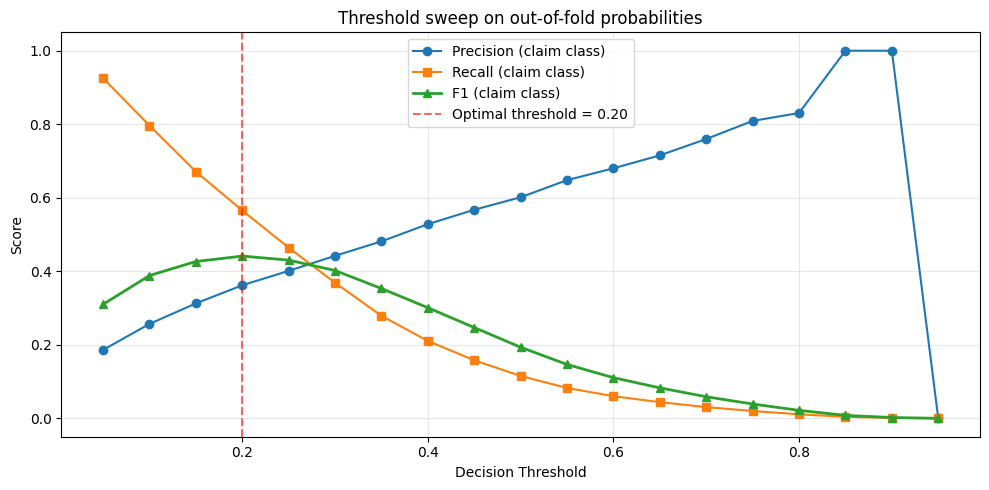

In [ ]:
# Plot precision, recall, and F1 across thresholds
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, marker='o', label='Precision (claim class)')
ax.plot(thresholds, recalls, marker='s', label='Recall (claim class)')
ax.plot(thresholds, f1_scores, marker='^', label='F1 (claim class)', linewidth=2)
ax.axvline(best_threshold, color='red', linestyle='--', alpha=0.6, label=f'Optimal threshold = {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold sweep on out-of-fold probabilities')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Diagnostic plots for the winning model

The plots below all use the out-of-fold probabilities and the optimal threshold. This is the most honest evaluation we can do without touching the actual test set.

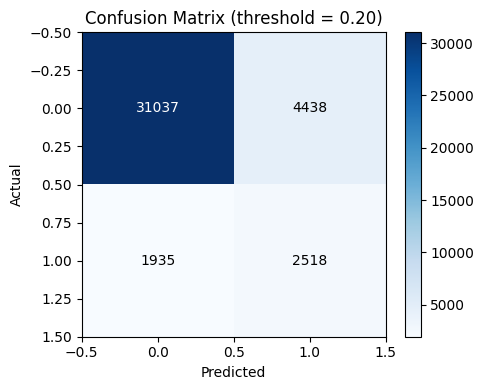

Classification report at optimal threshold:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91     35475
           1       0.36      0.57      0.44      4453

    accuracy                           0.84     39928
   macro avg       0.65      0.72      0.67     39928
weighted avg       0.88      0.84      0.85     39928

AUC (out-of-fold): 0.8296


In [ ]:
from sklearn.metrics import (confusion_matrix, RocCurveDisplay,
                              PrecisionRecallDisplay, classification_report)

y_pred_oof = (oof_proba >= best_threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_train_CS, y_pred_oof)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title(f'Confusion Matrix (threshold = {best_threshold:.2f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Classification report at optimal threshold:')
print(classification_report(y_train_CS, y_pred_oof))
print(f'AUC (out-of-fold): {roc_auc_score(y_train_CS, oof_proba):.4f}')

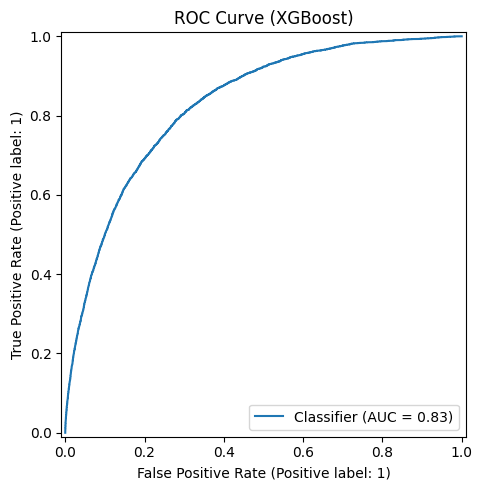

In [ ]:
# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_train_CS, oof_proba, ax=ax)
ax.set_title(f'ROC Curve ({winner_name})')
plt.tight_layout()
plt.show()

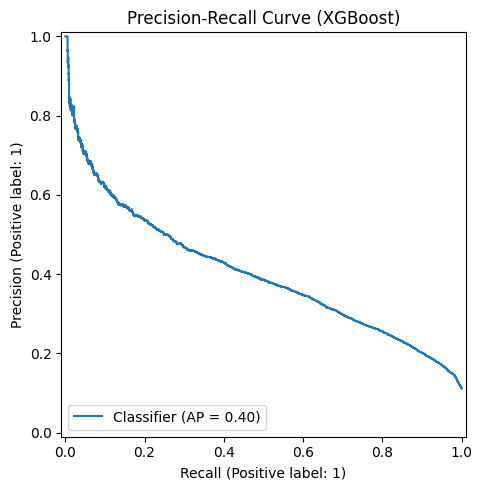

In [ ]:
# Precision-Recall curve
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_train_CS, oof_proba, ax=ax)
ax.set_title(f'Precision-Recall Curve ({winner_name})')
plt.tight_layout()
plt.show()

## Step 9: Feature importance for the winning model

We pull feature importance directly from the winning estimator. Logistic Regression returns coefficients (use the absolute value for ranking). Random Forest and XGBoost return tree-based importance scores.

The interpretation differs by model. For LR, a large positive coefficient means higher feature values push the prediction toward "claim". For tree models, the importance is symmetric and only tells you which features the model uses heavily.

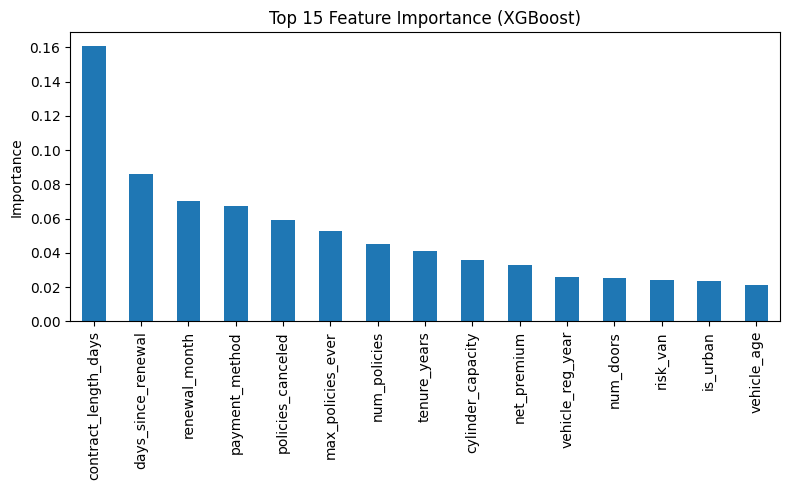

In [ ]:
if winner_name.startswith('Logistic'):
    # The pipeline's classifier is the second step
    coef = winner.named_steps['clf'].coef_[0]
    importance = pd.Series(np.abs(coef), index=X_train_CS.columns).sort_values(ascending=False)
    title = 'Top 15 |coefficient| (Logistic Regression L1)'
elif winner_name == 'Random Forest':
    importance = pd.Series(winner.feature_importances_, index=X_train_CS.columns).sort_values(ascending=False)
    title = 'Top 15 Feature Importance (Random Forest)'
else:
    importance = pd.Series(winner.feature_importances_, index=X_train_CS.columns).sort_values(ascending=False)
    title = 'Top 15 Feature Importance (XGBoost)'

fig, ax = plt.subplots(figsize=(8, 5))
importance.head(15).plot(kind='bar', ax=ax)
ax.set_title(title)
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()

## Step 10: Final test predictions

Now that model selection and threshold tuning are complete, we retrain the winning estimator on **all** 39,928 training records (no held-out validation slice) and apply the optimal threshold to predict CS for the 13,310 test records.

Why retrain on the full data. Cross-validation is for model selection; once we've selected, we want every available record going into the final fit. The five CV folds were always going to discard 20 percent of training for evaluation. That evaluation is done now, so we no longer need it.

In [ ]:
# Retrain the winning estimator on the full training data
print(f'Retraining {winner_name} on full training set...')
winner.fit(X_train_CS, y_train_CS)

# Predict probabilities on the actual test set
test_proba = winner.predict_proba(X_test_CS)[:, 1]

# Apply the optimal threshold to convert probabilities into 0/1 predictions
test_pred = (test_proba >= best_threshold).astype(int)

print(f'\nTest predictions generated.')
print(f'  Threshold used: {best_threshold:.2f}')
print(f'  Predicted claim rate: {test_pred.mean()*100:.1f}%')
print(f'  Predicted claim count: {test_pred.sum()} of {len(test_pred)}')

Retraining XGBoost on full training set...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:33:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Test predictions generated.
  Threshold used: 0.20
  Predicted claim rate: 17.2%
  Predicted claim count: 2289 of 13310


In [ ]:
# Save predictions to Drive. The file holds CS only.
## NOTE: The full submission file requires LC, HALC, and CS columns together.
## Merge this file with the regression teammates' LC and HALC predictions before submitting.
cs_out = pd.DataFrame({
    'CS': test_pred,
    'CS_proba': test_proba,
})
out_path = '/content/drive/MyDrive/machine_ learning_files/CS_predictions.csv'
cs_out.to_csv(out_path, index=False)
print(f'Saved CS predictions to: {out_path}')
cs_out.head()

Saved CS predictions to: /content/drive/MyDrive/machine_ learning_files/CS_predictions.csv


,CS,CS_proba
0,0,0.020603
1,0,0.034926
2,0,0.073495
3,0,0.114722
4,0,0.011994


## Summary

This notebook implements a defensible classification pipeline for the CS target.

1. **Leakage fix**. The first version of the model used `total_claims_history` (X.17), which the test set does not contain. Removing it lowered the apparent AUC from 0.93 to a realistic value but eliminated a guaranteed submission failure.
2. **Cross-validation**. All three model families were tuned and scored on the same 5-fold stratified splits, so the AUC numbers are directly comparable.
3. **Auto-pick by CV AUC**. The winning model is the one with the highest mean cross-validated AUC.
4. **Threshold tuning**. The decision threshold was selected by maximizing F1 on out-of-fold probabilities, not by accepting the default 0.50 cutoff.
5. **Test predictions**. The winning model was retrained on all training data and applied to the actual test CSV. Predictions are saved to `CS_predictions.csv`.

The model comparison table, threshold plot, and diagnostic plots above provide the figures and numbers that go into the report's classification section.